# **Eksplorasi Data**

### **Data** **Understanding**



- mengumpulkan data awal dan dilanjutkan dengan kegiatan untuk mendapatkan data yang lazim
- identifikasi data yang berkualitas
- pemahaman data yang sangat diperlukan untuk mengidentifikasi bagian yang menarik dari data

### **pentingnya Memahami Data**


membantu memilih teknik data mining yang tepat, meningkatkan akurasi model prediksi, menghindari kesalahan interpretasi, memastikan hasil yang dapat diandalkan dan dapat ditindaklanjuti.

### **komponen Utama Memahami Data**

1. Komponen: Pengumpulan Data Awal
   Penjelasan:
   Mengidentifikasi dan mengumpulkan semua sumber data yang relevan
   (database, file CSV, API, dll).

2. Komponen: Deskripsi Data
   Penjelasan:
   Memahami struktur data seperti jumlah baris/kolom, jenis variabel
   (numerik, kategorikal), nama atribut, serta contoh data.

3. Komponen: Eksplorasi Data (Exploratory Data Analysis / EDA)
   Penjelasan:
   Mencari pola, tren, korelasi, atau anomali dalam data.

4. Komponen: Kualitas Data
   Penjelasan:
   Memeriksa kelengkapan, keakuratan, dan konsistensi data.

### **Macam - Macam Data**

Dalam data data mining dan maha datar, Anda akan menemukan banyak jenis data yang berbeda, dan masing-masing cenderung membutuhkan alat dan teknik yang berbeda. Macam macam data dikelompokkan sebagai berikut:

- Data terstruktur (structured)
- Data tidak terstruktur(unstructured
- Data bahasa alami(Natural Language)
- Data yang dibangkit oleh Mesin (Machined-Generated)
- Data Audio, Video,Citra
- Data Streamming
- Data berbasis Graph(Graph-based)

### **Atribut**

atribut (dimensi) adalah menyatakan karakteristik atau fitur dari sata objek tipe-tipe :

- nominal/kategorikal
- ordinal
- biner
- numerik(interval-scaled, ratio-scaled)

## **menampilkan data iris**

Kumpulan data bunga Iris adalah kumpulan data multivariat yang diperkenalkan oleh ahli statistik dan biologi Inggris, Ronald Fisher, dalam makalahnya tahun 1936 yang berjudul “The use of multiple measurements in taxonomic problems”. Kumpulan data ini terkadang disebut sebagai kumpulan data Iris Anderson karena Edgar Anderson mengumpulkan data tersebut untuk mengukur variasi morfologi bunga Iris dari tiga spesies yang berkerabat. Kumpulan data ini terdiri dari 50 sampel dari masing-masing tiga spesies Iris (Iris Setosa, Iris virginica, dan Iris versicolor). Empat fitur diukur dari setiap sampel: panjang dan lebar sepal dan petal, dalam sentimeter.

- sepal_length → panjang kelopak
- sepal_width → lebar kelopak
- petal_length → panjang mahkota
- petal_width → lebar mahkota

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
iris_data = pd.read_csv("IRIS.csv")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(iris_data.head(10))
#display(iris_data.tail(10))
#display(iris_data)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


## menampilkan tipe data setiap fitur

In [ ]:
print("Info dataset: \n")
def tipe_data(dtype):
    if dtype in ['int64', 'float64']:
        return 'Numerik'
    elif dtype == 'bool':
        return 'Boolean'
    elif dtype == 'object':
        return 'Kategorikal'
    else:
        return str(dtype)  # untuk tipe lain

for col in iris_data.columns:
    print(f"{col}: {tipe_data(iris_data[col].dtype)}")

Info dataset: 

sepal_length: Numerik
sepal_width: Numerik
petal_length: Numerik
petal_width: Numerik
species: Kategorikal


In [ ]:
print("\nStatistik Deskriptif:")
display(iris_data.describe())

# Select only numerical columns for descriptive statistics
numerical_cols = iris_data.select_dtypes(include=np.number).columns


Statistik Deskriptif:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


1. Fitur: sepal_length
   Penjelasan:
   Nilai rata-rata (5.84) dan median (5.80) yang hampir sama menunjukkan distribusi data cukup seimbang (tidak terlalu miring).
   Modus sebesar 5.00 menandakan nilai yang paling sering muncul berada di sekitar angka tersebut.
   Rentang data cukup lebar, dari 4.30 hingga 7.90.
   Kuartil (Q1 = 5.10, Q3 = 6.40) menunjukkan sebagian besar data berada di antara nilai tersebut.
   Artinya, panjang sepal umumnya berada di kisaran sedang.

2. Fitur: sepal_width
   Penjelasan:
   Rata-rata (3.05), median (3.00), dan modus (3.00) sangat berdekatan, menunjukkan distribusi data yang stabil dan simetris.
   Nilai minimum 2.00 dan maksimum 4.40 menunjukkan variasi tidak terlalu ekstrem.
   Kuartil (Q1 = 2.80, Q3 = 3.30) menunjukkan sebagian besar data terkonsentrasi di sekitar nilai tengah.
   Artinya, lebar sepal cenderung konsisten di sekitar angka 3.

3. Fitur: petal_length
   Penjelasan:
   Rata-rata (3.76) cukup berbeda dengan median (4.35), menandakan distribusi data cenderung tidak simetris (miring).
   Modus 1.50 menunjukkan banyak data berada di nilai rendah.
   Rentang data sangat lebar (1.00 hingga 6.90), menandakan variasi tinggi.
   Kuartil menunjukkan perbedaan yang cukup besar antara Q1 (1.60) dan Q3 (5.10).
   Artinya, fitur ini memiliki pemisahan yang jelas (kemungkinan antar kelas bunga).

4. Fitur: petal_width
   Penjelasan:
   Rata-rata (1.20) dan median (1.30) cukup dekat, namun modus sangat kecil (0.20).
   Ini menunjukkan banyak data di nilai rendah, tetapi juga ada nilai tinggi.
   Rentang data dari 0.10 hingga 2.50 menunjukkan variasi cukup besar.
   Kuartil (Q1 = 0.30, Q3 = 1.80) menunjukkan distribusi data cukup menyebar.
   Artinya, lebar petal juga memiliki variasi tinggi dan berpotensi membedakan kelas data.

In [ ]:
for col in numerical_cols:
    mean_val = iris_data[col].mean()
    median_val = iris_data[col].median()
    mode_val = iris_data[col].mode()[0]
    min_val = iris_data[col].min()
    max_val = iris_data[col].max()

    q1 = iris_data[col].quantile(0.25)
    q2 = iris_data[col].quantile(0.50)
    q3 = iris_data[col].quantile(0.75)
    print(f"Fitur {col}:")
    print(f"- Rata-rata = {mean_val:.2f}")
    print(f"- Median (Q2) = {median_val:.2f}")
    print(f"- Modus = {mode_val:.2f}")
    print(f"- Minimum = {min_val:.2f}")
    print(f"- Q1 (25%) = {q1:.2f}")
    print(f"- Q2 (50%) = {q2:.2f}")
    print(f"- Q3 (75%) = {q3:.2f}")
    print(f"- Maximum = {max_val:.2f}")
    print("")

Fitur sepal_length:
- Rata-rata = 5.84
- Median (Q2) = 5.80
- Modus = 5.00
- Minimum = 4.30
- Q1 (25%) = 5.10
- Q2 (50%) = 5.80
- Q3 (75%) = 6.40
- Maximum = 7.90

Fitur sepal_width:
- Rata-rata = 3.05
- Median (Q2) = 3.00
- Modus = 3.00
- Minimum = 2.00
- Q1 (25%) = 2.80
- Q2 (50%) = 3.00
- Q3 (75%) = 3.30
- Maximum = 4.40

Fitur petal_length:
- Rata-rata = 3.76
- Median (Q2) = 4.35
- Modus = 1.50
- Minimum = 1.00
- Q1 (25%) = 1.60
- Q2 (50%) = 4.35
- Q3 (75%) = 5.10
- Maximum = 6.90

Fitur petal_width:
- Rata-rata = 1.20
- Median (Q2) = 1.30
- Modus = 0.20
- Minimum = 0.10
- Q1 (25%) = 0.30
- Q2 (50%) = 1.30
- Q3 (75%) = 1.80
- Maximum = 2.50



## Histogram untuk tiap fitur

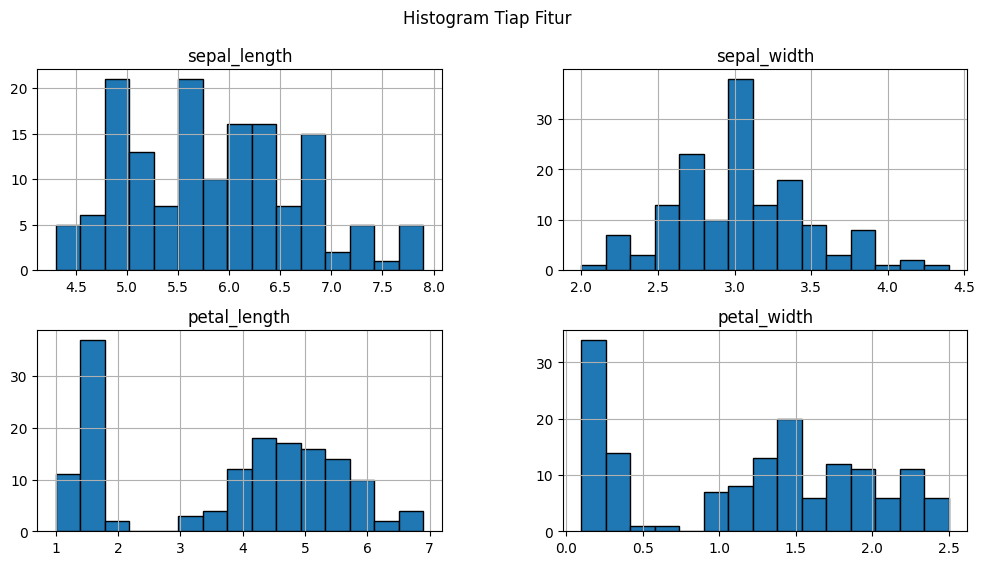

In [ ]:
iris_data.hist(bins=15, figsize=(12,6), edgecolor='black')
plt.suptitle("Histogram Tiap Fitur")
plt.show()

### **Analisis Fitur Dataset Iris (Histogram)**

1. **Sepal Length (Panjang Kelopak)**
   * **Rentang:** Sekitar 4.3 cm hingga 7.9 cm.
   * **Analisis:** Distribusinya cukup menyebar dan bersifat multimodal (memiliki beberapa puncak). Hal ini menunjukkan adanya tumpang tindih (overlap) nilai yang besar antara ketiga spesies Iris pada fitur ini.

2. **Sepal Width (Lebar Kelopak)**
   * **Rentang:** Sekitar 2.0 cm hingga 4.4 cm.
   * **Analisis:** Fitur ini memiliki distribusi yang paling mendekati Distribusi Normal (Bell Curve). Mayoritas sampel berkumpul di angka 3.0 cm. Fitur ini paling sulit digunakan untuk membedakan antar spesies karena datanya sangat berhimpit.

3. **Petal Length (Panjang Mahkota)**
   * **Rentang:** Sekitar 1.0 cm hingga 6.9 cm.
   * **Analisis:** Terlihat adanya pemisahan (gap) yang sangat jelas antara angka 2 dan 3. Kelompok di sisi kiri (1–2 cm) adalah spesies **Setosa**, sedangkan kelompok di sisi kanan adalah gabungan **Versicolor** dan **Virginica**.

4. **Petal Width (Lebar Mahkota)**
   * **Rentang:** Sekitar 0.1 cm hingga 2.5 cm.
   * **Analisis:** Mirip dengan Petal Length, terdapat pemisahan kelompok yang jelas. Nilai yang sangat rendah (0.1–0.6 cm) merupakan ciri khas utama spesies **Setosa**, memudahkan proses klasifikasi dibandingkan fitur Sepal.

## Boxplot untuk tiap fitur

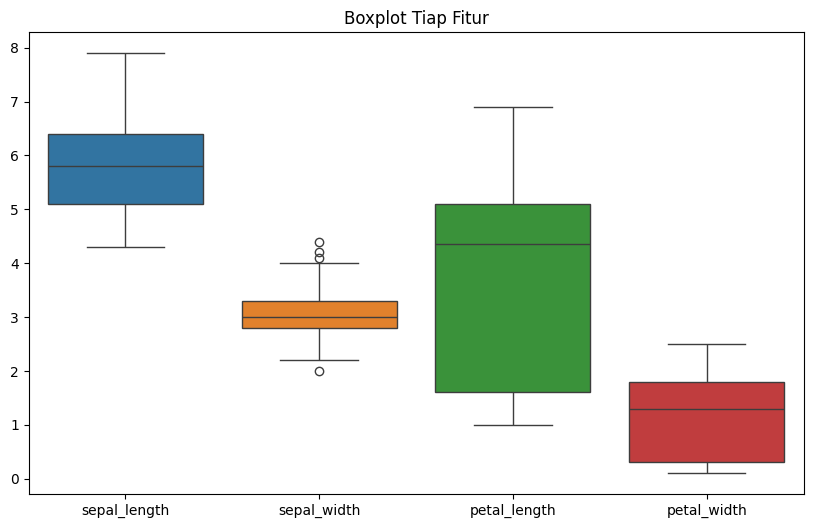

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=iris_data.select_dtypes(include=np.number))
plt.title("Boxplot Tiap Fitur")
plt.show()

## Scatter plot antara fitur

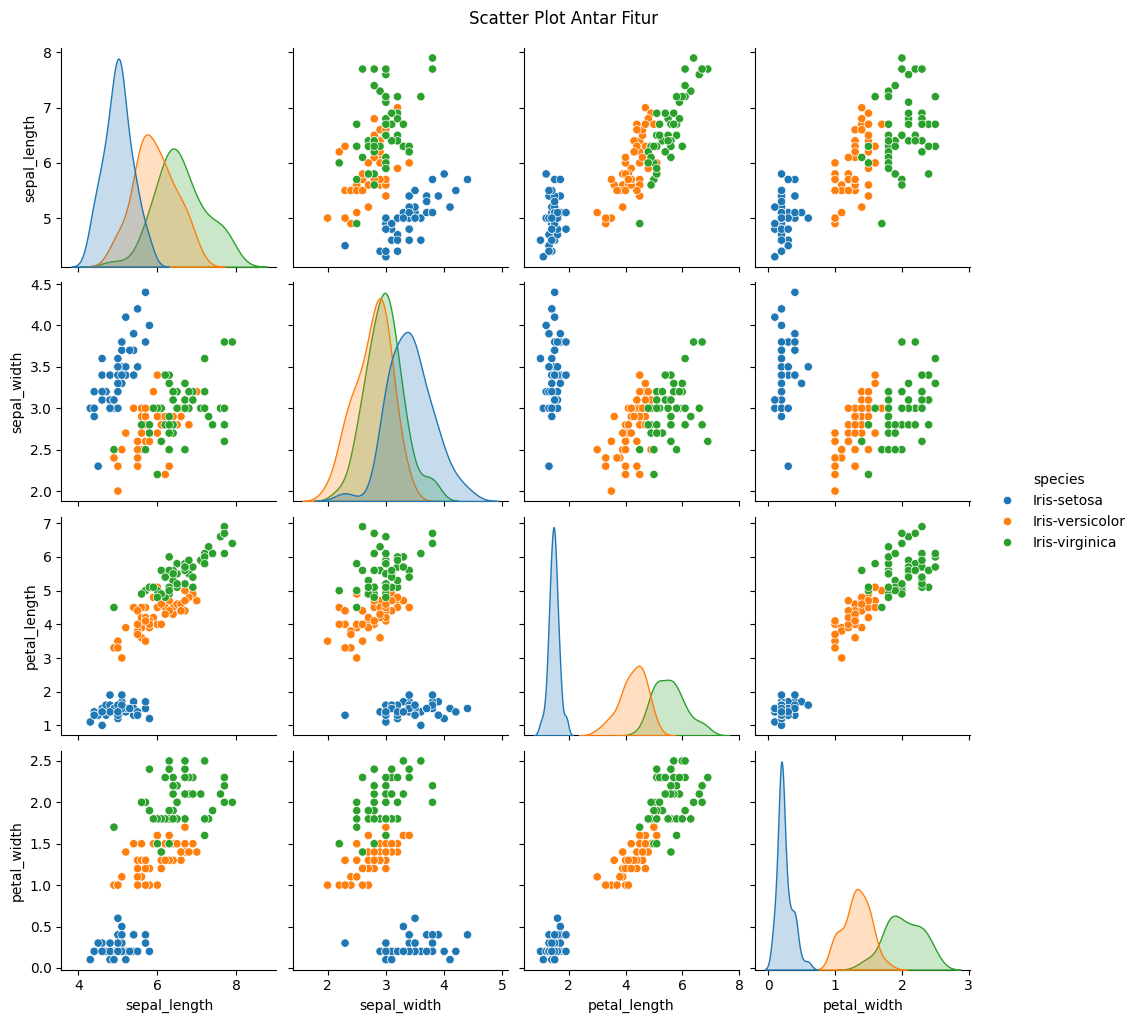

In [ ]:
sns.pairplot(iris_data, hue='species')
plt.suptitle("Scatter Plot Antar Fitur", y=1.02)
plt.show()